Zadanie Domowe 2

1. Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?

2. Nie doprowadź do przecieku statku wycieku danych (np. nie ucz modelu na danych testowych). 
Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.

3. Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie Dummy Classifier 
(jeśli Twój docelowy model radzi sobie gorzej - uciekaj)

4. Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką XGBoost)
W badaniach użyj wybranych metryk. Wybór uzasadnij.

5. Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów.     

6. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.

7. Podsumuj przeprowadzone badania, wypisz wnioski.

0* troche poprawiłem dane, 
encoding 'Sex' i 'Cabin' , uzupełnienie 'Age', 'Fare' i 'Embarked'

In [80]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
import warnings

from sklearn.experimental import enable_halving_search_cv 
from sklearn.model_selection import HalvingRandomSearchCV, train_test_split, cross_val_score, StratifiedKFold, ParameterGrid
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import SelectKBest, f_classif
from xgboost import XGBClassifier
from scipy.stats import loguniform, randint, uniform

warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [81]:
csv_path = Path('02_podstawy_aiml/titanic_ready.csv') if Path('02_podstawy_aiml/titanic_ready.csv').exists() else Path('titanic_ready.csv')
tytanik = pd.read_csv(csv_path)

print(tytanik.head()) 

   Survived  Pclass  Male   Age  SibSp  Parch     Fare  Has_Cabin  Embarked_C  \
0         0       3     1  22.0      1      0   7.2500          0           0   
1         1       1     0  38.0      1      0  71.2833          1           1   
2         1       3     0  26.0      0      0   7.9250          0           0   
3         1       1     0  35.0      1      0  53.1000          1           0   
4         0       3     1  35.0      0      0   8.0500          0           0   

   Embarked_Q  Embarked_S  
0           0           1  
1           0           0  
2           0           1  
3           0           1  
4           0           1  


wczytanie obrobionych, gotowych  danych z zadania 1 (plik \01_przetwarzanie_wizualizacja_danych\Homework.ipynb )

In [82]:


X = tytanik[['Pclass', 'Male', 'Age', 'SibSp', 'Parch', 'Fare', 'Has_Cabin', 'Embarked_C', 'Embarked_Q', 'Embarked_S']]
# posiadane dane
y = tytanik['Survived']
# obliczany wynik

zakres_parametrow = list(range(1, 31))
zakres_cech = list(range(1, 11))
# zakres parametrów i cech

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


2. trenowanie modelu, odzielenie danych treningowych od testowych

In [83]:
baseline_model = DummyClassifier(strategy='most_frequent')

# 3. moim baselinem będzię DummyClassifier
baseline_cv_scores = cross_val_score(baseline_model, X_train, y_train, cv=5)
print(f"--- Baseline (DummyClassifier): {baseline_cv_scores.mean():.3f} ---\n")

--- Baseline (DummyClassifier): 0.624 ---



In [84]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modele_do_sprawdzenia = {
    'Drzewo Decyzyjne': {
        'model': Pipeline([
            ('skb', SelectKBest(score_func=f_classif)), 
            ('dt', DecisionTreeClassifier(random_state=42))
        ]),
        'parametry': {
            'skb__k': zakres_cech,
            'dt__max_depth': zakres_parametrow,
            'dt__criterion': ['gini', 'entropy', 'log_loss'],
            'dt__min_samples_leaf': zakres_parametrow,
            'dt__min_samples_split': zakres_parametrow[1:], 
            'dt__max_features': ['sqrt', 'log2', None],
            'dt__splitter': ['best', 'random']
        }
    },
    'KNN': {
        'model': Pipeline([
            ('skaler', StandardScaler()),
            ('skb', SelectKBest(score_func=f_classif)),
            ('knn', KNeighborsClassifier())
        ]),
        'parametry': {
            'skb__k': zakres_cech,
            'knn__n_neighbors': zakres_parametrow[::2], # nieparzyste liczby sąsiadów
            'knn__weights': ['uniform', 'distance'],
            'knn__metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski'],
            'knn__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
            'knn__p': [1, 2, 3]
        }
    },
    'SVM': {
        'model': Pipeline([
            ('skaler', StandardScaler()),
            ('skb', SelectKBest(score_func=f_classif)),
            ('svm', SVC(random_state=42))
        ]),
        'parametry': {
            'skb__k': zakres_cech,
            'svm__C': loguniform(1e-3, 1e2),
            'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
            'svm__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
            'svm__degree': zakres_parametrow[:6] 
        }
    },
    'Sieć Neuronowa (MLP)': {
        'model': Pipeline([
            ('skaler', StandardScaler()),
            ('skb', SelectKBest(score_func=f_classif)),
            ('mlp', MLPClassifier(max_iter=500, random_state=42))
        ]),
        'parametry': {
            'skb__k': zakres_cech,
            'mlp__hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (100, 100)],
            'mlp__activation': ['relu', 'tanh', 'logistic', 'identity'],
            'mlp__solver': ['adam', 'lbfgs', 'sgd'],
            'mlp__alpha': [0.0001, 0.001, 0.01, 0.1]
        }
    },
    'XGBoost': {  
        'model': Pipeline([
            ('skb', SelectKBest(score_func=f_classif)),
            ('xgb', XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0, n_jobs=1))
        ]),
        'parametry': {
            'skb__k': zakres_cech,
            'xgb__n_estimators': [50, 100, 200, 300],
            'xgb__max_depth': randint(1, 11),
            'xgb__min_child_weight': zakres_parametrow[:5],
            'xgb__learning_rate': loguniform(1e-3, 3e-1),
            'xgb__gamma': [0, 0.1, 0.2], 
            'xgb__subsample': [0.7, 0.8, 1.0]
        }
    }
}



4. (wybrałem wicęj niż dwa) testujemy różne algorytmy z różnymi parametrami
dzieki temu nie musze na początku wybierać algorytmu

5. wybieram kilka parametrów na algorytm (im wiecej tym bardziej moge dostosowywać)
po dopasowaniu najlepszych (znalezionych) parametrów moge wybrać algorytm

In [85]:
print("--- Optymalizacja wielu modeli (HalvingRandomSearchCV) ---")

najlepsze_modele = {}

for nazwa, konfiguracja in modele_do_sprawdzenia.items():
    print(f"Optymalizacja dla: {nazwa}...")
    
    ilosc_iteracji = 300  # <--- ZMIENIASZ ILOŚĆ ITERACJI W TYM MIEJSCU
    try:
        l_kombinacji = len(ParameterGrid(konfiguracja['parametry']))
        n_cand = min(ilosc_iteracji, l_kombinacji)
    except TypeError:
        n_cand = ilosc_iteracji

    szukaj = HalvingRandomSearchCV(
        estimator=konfiguracja['model'],
        param_distributions=konfiguracja['parametry'],
        n_candidates=n_cand,
        # ilość kombinacji do przetestowania
        
        min_resources=40,
        cv=skf,
        scoring='accuracy',
        random_state=42,
        n_jobs=1
    )
    szukaj.fit(X_train, y_train)
    najlepsze_modele[nazwa] = szukaj 
    
    print(f"Najlepszy wynik (CV): {szukaj.best_score_:.3f}")
    print(f"Najlepsze parametry: {szukaj.best_params_}\n")

--- Optymalizacja wielu modeli (HalvingRandomSearchCV) ---
Optymalizacja dla: Drzewo Decyzyjne...
Najlepszy wynik (CV): 0.826
Najlepsze parametry: {'skb__k': 5, 'dt__splitter': 'random', 'dt__min_samples_split': 5, 'dt__min_samples_leaf': 13, 'dt__max_features': None, 'dt__max_depth': 13, 'dt__criterion': 'gini'}

Optymalizacja dla: KNN...
Najlepszy wynik (CV): 0.832
Najlepsze parametry: {'skb__k': 7, 'knn__weights': 'distance', 'knn__p': 1, 'knn__n_neighbors': 15, 'knn__metric': 'minkowski', 'knn__algorithm': 'kd_tree'}

Optymalizacja dla: SVM...
Najlepszy wynik (CV): 0.815
Najlepsze parametry: {'skb__k': 2, 'svm__C': np.float64(0.11057854100925227), 'svm__degree': 4, 'svm__gamma': 'auto', 'svm__kernel': 'poly'}

Optymalizacja dla: Sieć Neuronowa (MLP)...
Najlepszy wynik (CV): 0.821
Najlepsze parametry: {'skb__k': 4, 'mlp__solver': 'lbfgs', 'mlp__hidden_layer_sizes': (100, 100), 'mlp__alpha': 0.1, 'mlp__activation': 'logistic'}

Optymalizacja dla: XGBoost...
Najlepszy wynik (CV): 0.83

In [86]:
print("--- Ostateczne starcie na zbiorze testowym ---")

for nazwa, zoptymalizowany_model in najlepsze_modele.items():
    print(f"\n===== Wyniki dla: {nazwa} =====")
    y_pred = zoptymalizowany_model.predict(X_test)
    print(classification_report(y_test, y_pred))
    print("Macierz pomyłek:")
    print(confusion_matrix(y_test, y_pred))

--- Ostateczne starcie na zbiorze testowym ---

===== Wyniki dla: Drzewo Decyzyjne =====
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       105
           1       0.76      0.69      0.72        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179

Macierz pomyłek:
[[89 16]
 [23 51]]

===== Wyniki dla: KNN =====
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

Macierz pomyłek:
[[92 13]
 [19 55]]

===== Wyniki dla: SVM =====
              precision    recall  f1-score   support

           0       0.73      0.96      0.83       105
           1      

6. teraz moge porównać wynik dla wszystkich algorytmów 
zapisuje najlepsze algorytmy z parametrami do pliku
w przyszłości można wczytywać plik z parametrami do modelu albo wyksportoć osobny plik wytrenowanego modelu

In [87]:
from datetime import datetime
from datetime import datetime
import json

teraz = datetime.now()
znacznik_czasu = teraz.strftime('%Y-%m-%d_%H-%M-%S')

# pliki będę nazywał przez date 
nazwa_pliku = f'najlepsze_parametry_{znacznik_czasu}.json'


sciezka_parametry =( 
    Path('02_podstawy_aiml') / nazwa_pliku 
    if Path('02_podstawy_aiml').exists() 
    else Path(nazwa_pliku) )

wszystkie_parametry = {}

for nazwa, szukaj in najlepsze_modele.items():
    czyste_parametry = {
        'wynik_cv': round(float(szukaj.best_score_), 4),
        'wynik_test': round(float(szukaj.score(X_test, y_test)), 4)
    }
    for k, v in szukaj.best_params_.items():
        if hasattr(v, 'item'):
            czyste_parametry[k] = v.item()
        else:
            czyste_parametry[k] = v
    wszystkie_parametry[nazwa] = czyste_parametry

with open(sciezka_parametry, 'w', encoding='utf-8') as plik:
    json.dump(wszystkie_parametry, plik, indent=4, ensure_ascii=False)

print(f'Zapisano plik: {sciezka_parametry}\n')

df_parametry = pd.DataFrame.from_dict(wszystkie_parametry, orient='index')
print(df_parametry.head())

Zapisano plik: najlepsze_parametry_2026-08-24_15-19-47.json

                      wynik_cv  wynik_test  skb__k dt__splitter  \
Drzewo Decyzyjne        0.8265      0.7821       5       random   
KNN                     0.8321      0.8212       7          NaN   
SVM                     0.8152      0.7654       2          NaN   
Sieć Neuronowa (MLP)    0.8210      0.7877       4          NaN   
XGBoost                 0.8377      0.8101       8          NaN   

                      dt__min_samples_split  dt__min_samples_leaf  \
Drzewo Decyzyjne                        5.0                  13.0   
KNN                                     NaN                   NaN   
SVM                                     NaN                   NaN   
Sieć Neuronowa (MLP)                    NaN                   NaN   
XGBoost                                 NaN                   NaN   

                      dt__max_features  dt__max_depth dt__criterion  \
Drzewo Decyzyjne                   NaN           1

zapisuje parametry w pliku JSON, z nazewnictwem aktulanego czasu
w przyszłości można zachowywać historie plików aby monitorować jak zmieniają się parametry wzgledem treningów


--- Generowanie wykresu Feature Importance (XGBoost) ---

Ważność cech (XGBoost):
     Cecha  Ważność
      Male 0.645174
    Pclass 0.113133
 Has_Cabin 0.098291
Embarked_S 0.033400
      Fare 0.030922
Embarked_C 0.026455
     SibSp 0.026319
     Parch 0.026306


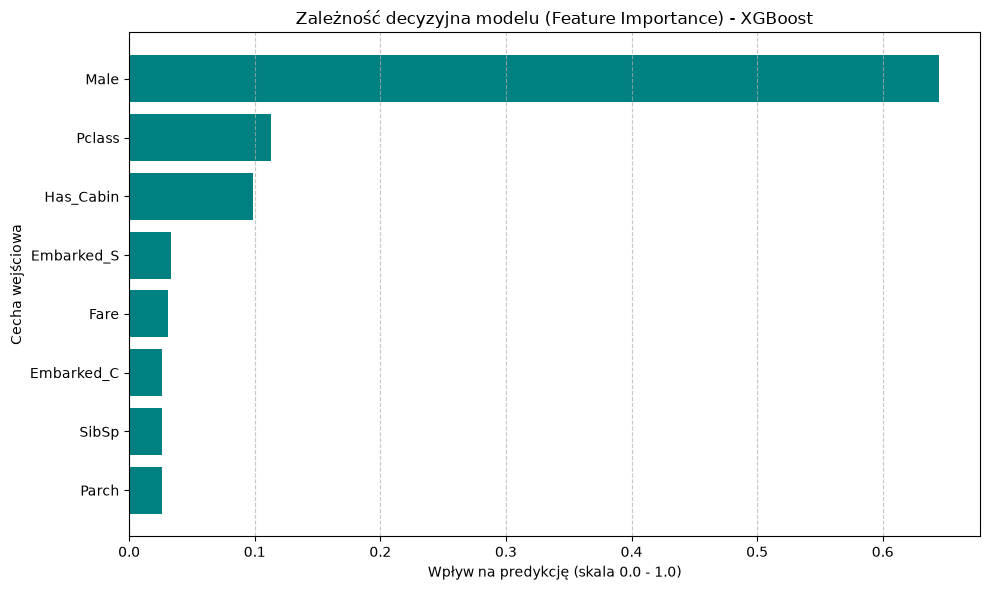

In [88]:
print("\n--- Generowanie wykresu Feature Importance (XGBoost) ---")

najlepszy_potok_xgb = najlepsze_modele['XGBoost'].best_estimator_
selektor_cech = najlepszy_potok_xgb.named_steps['skb']
model_xgb = najlepszy_potok_xgb.named_steps['xgb']

wybrane_maska = selektor_cech.get_support()
nazwy_wybranych_cech = X.columns[wybrane_maska]
wagi = model_xgb.feature_importances_

df_wagi = pd.DataFrame({
    'Cecha': nazwy_wybranych_cech,
    'Ważność': wagi
}).sort_values(by='Ważność', ascending=False)

print("\nWażność cech (XGBoost):")
print(df_wagi.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(df_wagi['Cecha'][::-1], df_wagi['Ważność'][::-1], color='teal')
plt.title('Zależność decyzyjna modelu (Feature Importance) - XGBoost')
plt.xlabel('Wpływ na predykcję (skala 0.0 - 1.0)')
plt.ylabel('Cecha wejściowa')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

7.wybrałem kaktyke 'ma działać' biorąc pod uwage tylko wynik, troche nie miałem pomysłu jak analizowąc wyniki
najlepsze wyniki są w okoliczy 82% +- 0,3% , zwiększająć ilość interacji oraz zakres samych parametów (jak ich rodzajów) 
może uzyskałbym lepsze wyniki

może był by jakiś lepszy sposób na lepsze obliczanie wariantów oraz wyników, 
jakąś opcją byłoby dodanie licznika treningowego który by przerywał trening jezeli trawał by on za długo (dla 300 iteracji trał prawie 10 min)

lub poprostu ulepszyć dane (usunąć szum, przefiltrować itp) bo to one mogą być wąskim gadłem